# SEA detector comparison inside STUDD

This notebook compares different drift detectors inside the STUDD mechanism on the synthetic SEA dataset.

The goal is to evaluate which detector produces the most useful alarms with respect to the known true drift point.

For each detector, we record:

- all STUDD alarms
- the alarm closest to the true drift
- teacher accuracy around the true drift
- teacher-student disagreement around the true drift
- teacher accuracy around the closest alarm
- teacher-student disagreement around the closest alarm

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from capymoa.stream.generator import SEA as CapySEA
from capymoa.stream.drift import DriftStream, Drift

from capymoa.drift.detectors import (
    STUDD,
    ADWIN,
    PageHinkley,
    HDDMAverage,
    HDDMWeighted,
    CUSUM,
)

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_rf,
    make_student,
    collect_instances,
)

configure_matplotlib()

## Experimental parameters

The SEA stream contains one abrupt concept drift (t=5000).

The teacher is trained on the first `W` samples and remains fixed during monitoring.

The student learns to mimic the teacher, while STUDD monitors teacher-student agreement using different drift detectors.

In [2]:
SEED = 42

n1 = 2000
n2 = 10000

W = n1
drift_pos = 5000

f_old_moa = 1
f_new_moa = 3

N_TREES = 100
STUDENT_TYPE = "ht"

LOCAL_WINDOW = 100
ROLLING_WINDOW = 200

## Detectors

We compare five detectors inside STUDD.

Page-Hinkley is configured with `delta=0.001`.

In [3]:
DETECTORS = {
    "ADWIN": lambda: ADWIN(),
    "PageHinkley": lambda: PageHinkley(delta=0.001),
    "HDDMAverage": lambda: HDDMAverage(),
    "HDDMWeighted": lambda: HDDMWeighted(),
    "CUSUM": lambda: CUSUM(),
}

## Run STUDD with each detector

For each detector, we recreate the same SEA stream, train the same teacher model, initialize the same student model and run STUDD.

This ensures that the only changing component is the drift detector inside STUDD.

In [4]:
comparison_runs = {}

for detector_name, detector_factory in DETECTORS.items():

    print(f"Running {detector_name}...")

    drift_stream = DriftStream(stream=[
        CapySEA(
            function=f_old_moa,
            instance_random_seed=SEED + 10,
            noise_percentage=0,
            balance_classes=True,
        ),
        Drift(position=drift_pos, width=0),
        CapySEA(
            function=f_new_moa,
            instance_random_seed=SEED + 20,
            noise_percentage=0,
            balance_classes=True,
        ),
    ])

    schema = drift_stream.get_schema()

    teacher = make_rf(
        schema=schema,
        seed=SEED,
        n_trees=N_TREES,
    )

    reference_instances = collect_instances(
        drift_stream,
        W,
    )

    for inst in reference_instances:
        teacher.train(inst)

    student = make_student(
        schema=schema,
        student_type=STUDENT_TYPE,
        seed=SEED,
        n_trees=N_TREES,
    )

    studd = STUDD(
        student=student,
        min_n_instances=W,
        detector=detector_factory(),
    )

    records = []
    studd_drift_points = []

    processed = W

    while drift_stream.has_more_instances() and processed < n2:

        inst = drift_stream.next_instance()

        y_true = inst.y_index
        y_teacher = teacher.predict(inst)

        if y_teacher is None:
            processed += 1
            continue

        teacher_correct = int(y_teacher == y_true)

        studd.add_element(
            inst,
            y_teacher,
        )

        detected_change = studd.detected_change()

        if detected_change:
            studd_drift_points.append(
                int(processed)
            )

        records.append({
            "t": int(processed),
            "teacher_correct": teacher_correct,
            "drift_alarm": detected_change,
        })

        processed += 1

    results = pd.DataFrame(records)

    agreement = np.array(
        studd.data,
        dtype=float,
    )

    disagreement = 1.0 - agreement

    agreement_idx = (
        np.arange(len(agreement))
        + studd.min_n_instances
    )

    closest_alarm = (
        min(
            studd_drift_points,
            key=lambda alarm: abs(alarm - drift_pos),
        )
        if studd_drift_points
        else None
    )

    closest_alarm_delay = (
        closest_alarm - drift_pos
        if closest_alarm is not None
        else None
    )

    # Metrics around the true drift

    true_drift_before_disagreement = disagreement[
        (agreement_idx >= drift_pos - LOCAL_WINDOW)
        &
        (agreement_idx < drift_pos)
    ]

    true_drift_after_disagreement = disagreement[
        (agreement_idx >= drift_pos)
        &
        (agreement_idx < drift_pos + LOCAL_WINDOW)
    ]

    true_drift_before_accuracy = results[
        (results["t"] >= drift_pos - LOCAL_WINDOW)
        &
        (results["t"] < drift_pos)
    ]["teacher_correct"]

    true_drift_after_accuracy = results[
        (results["t"] >= drift_pos)
        &
        (results["t"] < drift_pos + LOCAL_WINDOW)
    ]["teacher_correct"]

    # Metrics around the alarm closest to the true drift

    if closest_alarm is not None:

        closest_alarm_before_disagreement = disagreement[
            (agreement_idx >= closest_alarm - LOCAL_WINDOW)
            &
            (agreement_idx < closest_alarm)
        ]

        closest_alarm_after_disagreement = disagreement[
            (agreement_idx >= closest_alarm)
            &
            (agreement_idx < closest_alarm + LOCAL_WINDOW)
        ]

        closest_alarm_before_accuracy = results[
            (results["t"] >= closest_alarm - LOCAL_WINDOW)
            &
            (results["t"] < closest_alarm)
        ]["teacher_correct"]

        closest_alarm_after_accuracy = results[
            (results["t"] >= closest_alarm)
            &
            (results["t"] < closest_alarm + LOCAL_WINDOW)
        ]["teacher_correct"]

    else:

        closest_alarm_before_disagreement = np.array([])
        closest_alarm_after_disagreement = np.array([])

        closest_alarm_before_accuracy = pd.Series(dtype=float)
        closest_alarm_after_accuracy = pd.Series(dtype=float)

    summary = {
        "detector": detector_name,

        "num_alarms": len(studd_drift_points),
        "alarms": studd_drift_points,

        "closest_alarm": closest_alarm,
        "closest_alarm_delay": closest_alarm_delay,

        "true_drift_accuracy_delta": (
            true_drift_after_accuracy.mean()
            - true_drift_before_accuracy.mean()
        ),

        "true_drift_disagreement_delta": (
            true_drift_after_disagreement.mean()
            - true_drift_before_disagreement.mean()
        ),

        "closest_alarm_accuracy_delta": (
            closest_alarm_after_accuracy.mean()
            - closest_alarm_before_accuracy.mean()
        ),

        "closest_alarm_disagreement_delta": (
            closest_alarm_after_disagreement.mean()
            - closest_alarm_before_disagreement.mean()
        ),
    }

    comparison_runs[detector_name] = {
        "summary": summary,
        "results": results,
        "agreement_idx": agreement_idx,
        "agreement": agreement,
        "disagreement": disagreement,
        "studd_drift_points": studd_drift_points,
    }

print("Done.")

Running ADWIN...


Running PageHinkley...
Running HDDMAverage...
Running HDDMWeighted...
Running CUSUM...
Done.


## Summary table

This table contains all metrics collected for each detector.

The most important column is `closest_alarm_distance`, because it shows how close the detector came to the known true drift point.

For SEA, a good detector should ideally:

- detect close to the true drift
- avoid many false alarms
- show meaningful disagreement behaviour around the detected alarm

In [5]:
summary_df = pd.DataFrame([
    run["summary"]
    for run in comparison_runs.values()
])

summary_df = (
    summary_df
    .sort_values("closest_alarm_delay", key=lambda s: s.abs(), na_position="last")
    .reset_index(drop=True)
)

summary_df

,detector,num_alarms,alarms,closest_alarm,closest_alarm_delay,true_drift_accuracy_delta,true_drift_disagreement_delta,closest_alarm_accuracy_delta,closest_alarm_disagreement_delta
0,CUSUM,3,"[4992, 7494, 8688]",4992,-8,-0.04,-0.07,-0.04,-0.02
1,ADWIN,8,"[4836, 4900, 5028, 8135, 8295, 8647, 8839, 9225]",5028,28,-0.04,-0.07,-0.05,-0.04
2,PageHinkley,2,"[5081, 8051]",5081,81,-0.04,-0.07,0.03,0.05
3,HDDMWeighted,4,"[4794, 6841, 8399, 9833]",4794,-206,-0.04,-0.07,-0.01,0.00
4,HDDMAverage,3,"[4780, 7530, 8597]",4780,-220,-0.04,-0.07,0.00,-0.05


## Rolling teacher accuracy

The following plots show the rolling teacher accuracy for each detector run.

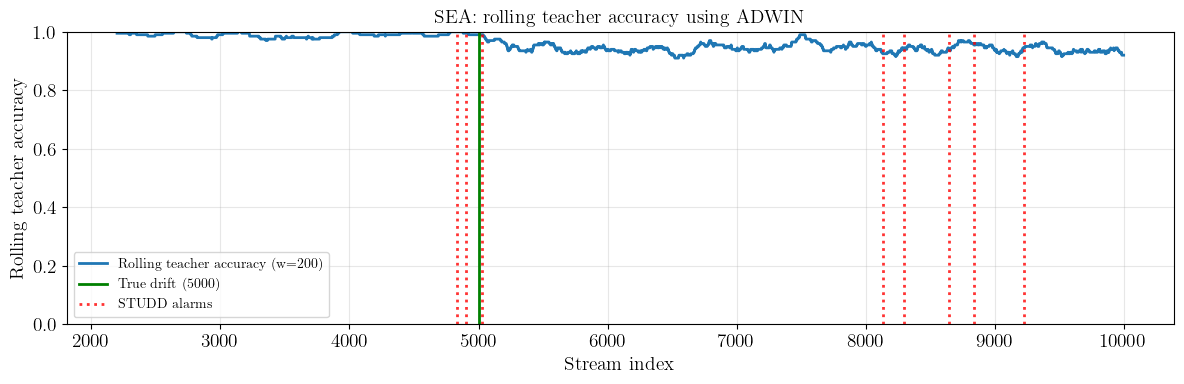

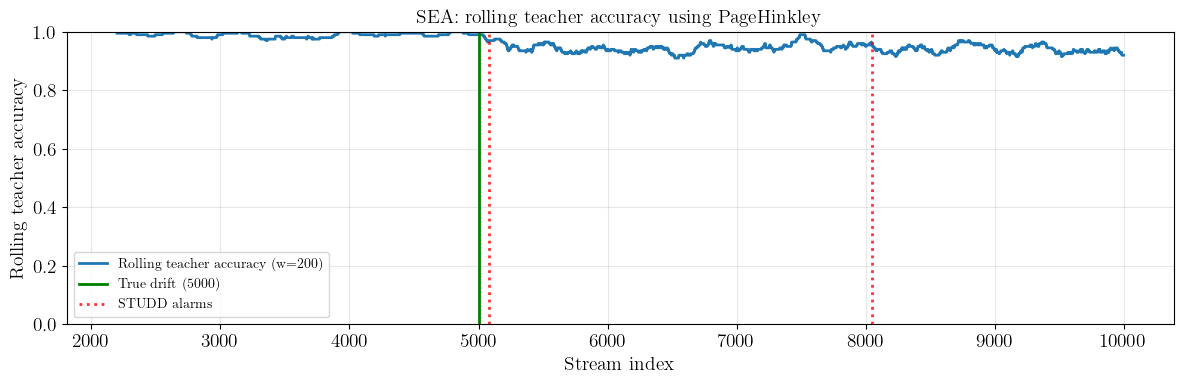

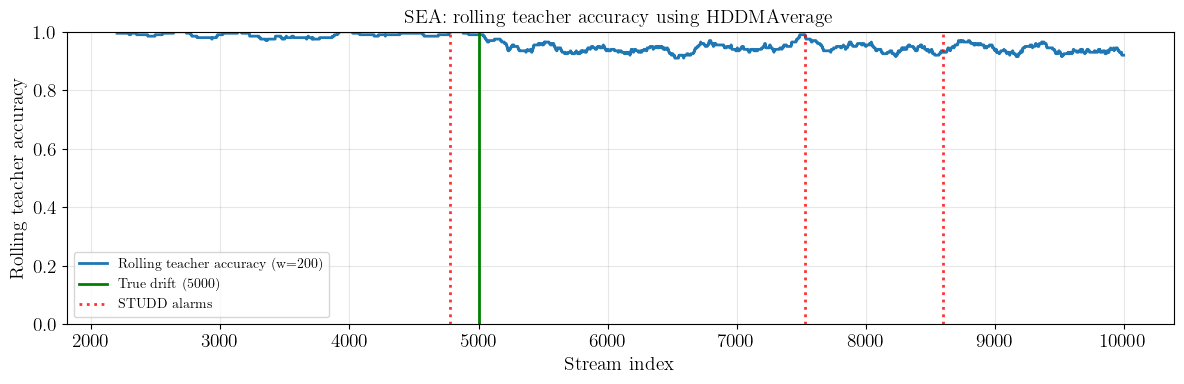

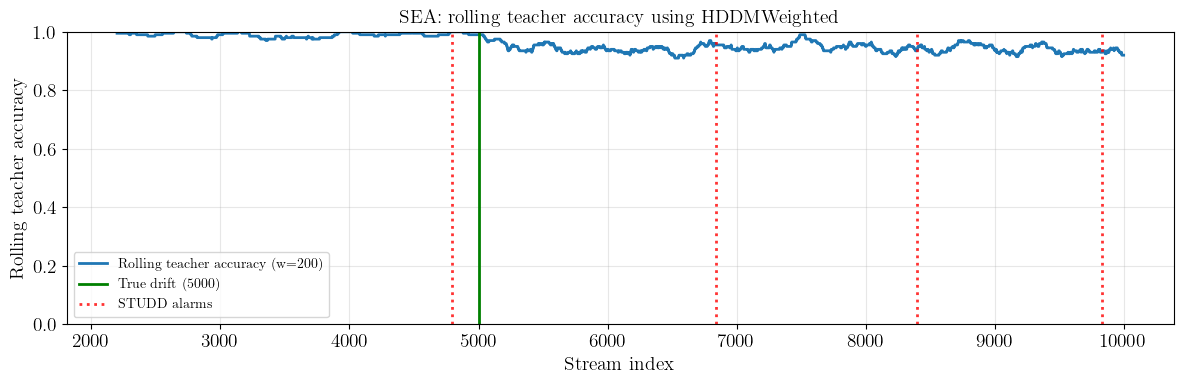

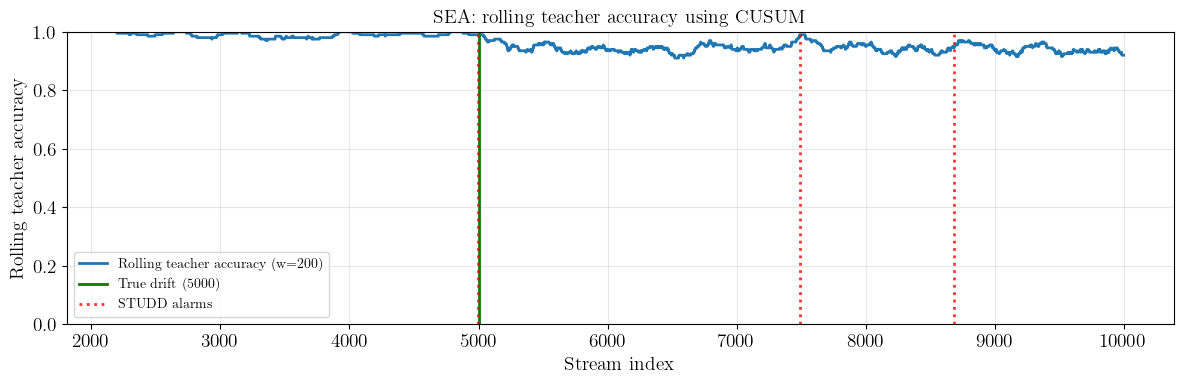

In [6]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_accuracy, _ = rolling_mean(
        results["teacher_correct"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_accuracy,
        linewidth=2,
        label=f"Rolling teacher accuracy (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        drift_pos,
        color="green",
        linewidth=2,
        label=f"True drift ({drift_pos})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"SEA: rolling teacher accuracy using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling teacher accuracy")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Rolling teacher-student disagreement

The following plots show the rolling teacher-student disagreement for each detector.

This is the signal monitored by STUDD.

Detector alarms are shown as red dotted lines.

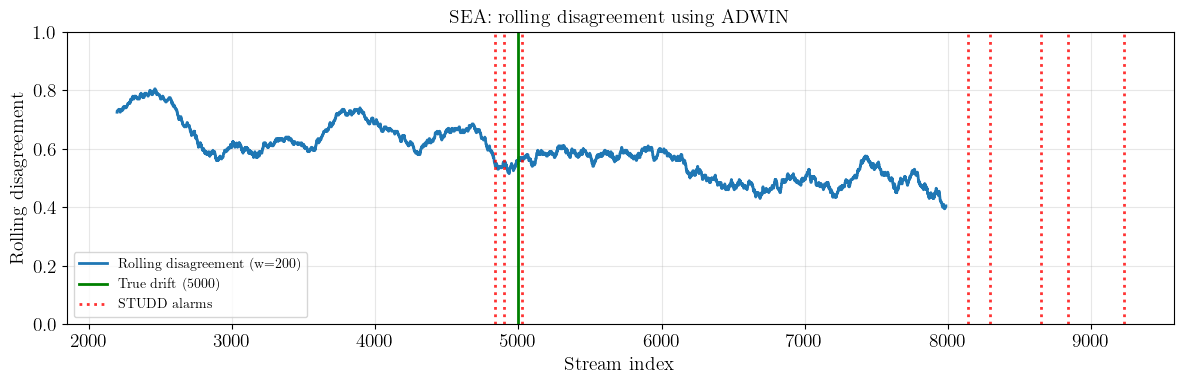

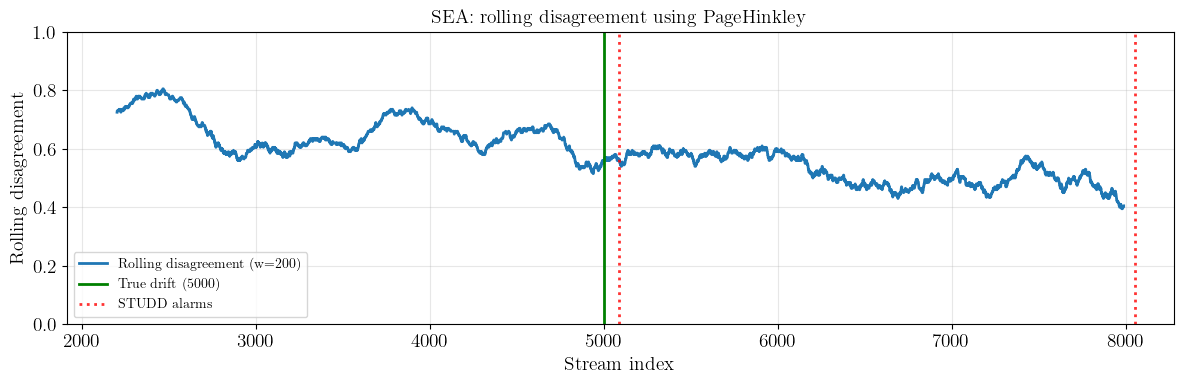

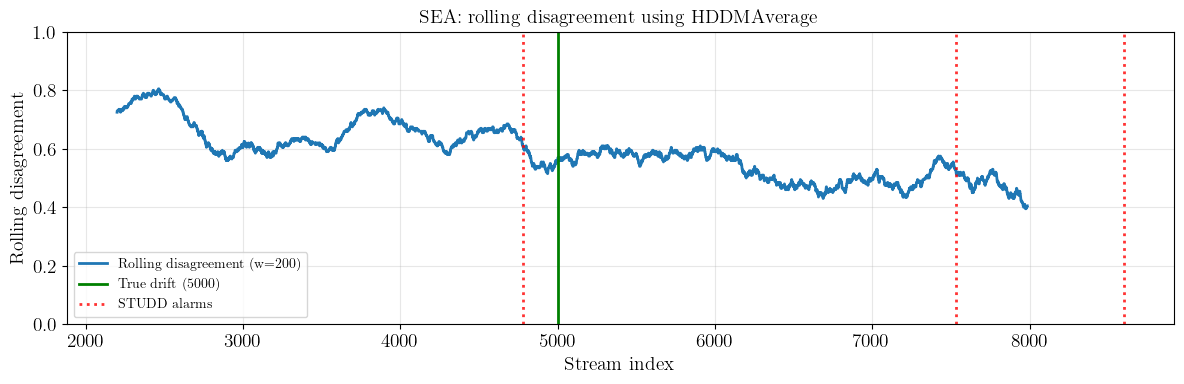

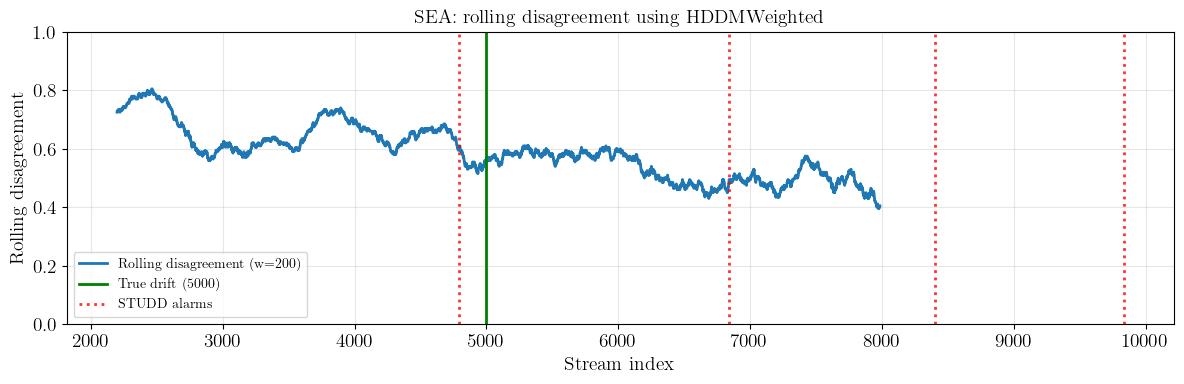

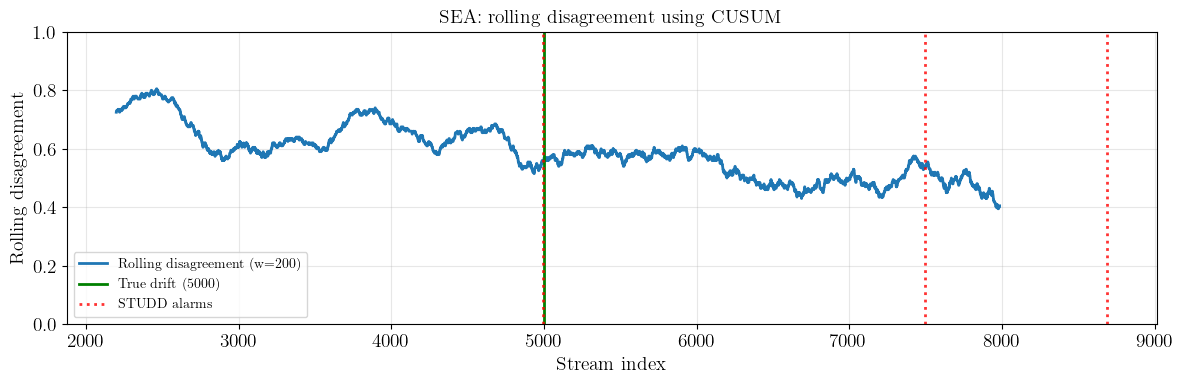

In [7]:
for detector_name, run in comparison_runs.items():

    agreement_idx = run["agreement_idx"]
    disagreement = run["disagreement"]
    alarms = run["studd_drift_points"]

    rolling_disagreement, _ = rolling_mean(
        disagreement,
        ROLLING_WINDOW,
    )

    rolling_t = agreement_idx[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_disagreement,
        linewidth=2,
        label=f"Rolling disagreement (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        drift_pos,
        color="green",
        linewidth=2,
        label=f"True drift ({drift_pos})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"SEA: rolling disagreement using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling disagreement")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation

This notebook compares the effect of changing only the detector inside STUDD.

The key quantities are:

- closest alarm distance:  how close the detector alarm is to the true drift
- false alarms:  whether the detector raises alarms too early or too late
- number of alarms:  whether the detector is too sensitive
- true drift disagreement delta:  whether disagreement changes around the true drift
- closest alarm disagreement delta:  whether disagreement changes around the detector's closest alarm

A detector is preferable if it detects close to the true drift, avoids excessive false alarms and reacts to meaningful changes in teacher-student disagreement.